# TTC Production Run — Exploratory Data Analysis of Reranker Minimization Threshold

First production batch from APHL (2026-06 eICRs). This notebook parses every
`TTCMetadataV2` record into one tidy table and explores whether we might be able to implement a reranker minimization threshold.


In [ ]:
pip install pandas matplotlib pyarrow seaborn numpy

In [218]:
# --- Config -------------------------------------------------------------
# Run locally against the downloaded archive (fast, free), or in Azure ML
# against the datastore (set USE_LOCAL=False on a compute instance).
USE_LOCAL = True

LOCAL_ROOT = "C://Users/Marcelle/Downloads/ttc-output-0625-full"      # the unzipped archive
DATASTORE_PREFIX = "ttc-output-0625-full"            # folder we uploaded to workspaceblobstore
CACHE_PARQUET = "ttc_candidates.parquet"             # parsed cache (reload instantly)

import glob, json, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option("display.max_colwidth", 60)


In [224]:
# --- Loader -------------------------------------------------------------
def _iter_metadata_files():
    """Yield (path_label, json_text) for every TTCMetadataV2 record."""
    if USE_LOCAL:
        root = os.path.join(os.path.expanduser(LOCAL_ROOT), "TTCMetadataV2")
        for fp in glob.glob(os.path.join(root, "**", "*.json"), recursive=True):
            with open(fp) as f:
                yield fp, f.read()
    else:
        # Azure ML: read straight from the workspaceblobstore datastore.
        from azure.identity import DefaultAzureCredential
        from azure.keyvault.secrets import SecretClient
        from azureml.fsspec import AzureMachineLearningFileSystem
        sc = SecretClient("https://dibbsttc6059789213.vault.azure.net/", DefaultAzureCredential())
        sub, rg, ws = (sc.get_secret(k).value for k in ("subscription", "resource-group", "workspace-name"))
        fs = AzureMachineLearningFileSystem(
            f"azureml://subscriptions/{sub}/resourcegroups/{rg}/workspaces/{ws}/datastores/workspaceblobstore"
        )
        for fp in fs.glob(f"{DATASTORE_PREFIX}/TTCMetadataV2/**/*.json"):
            with fs.open(fp) as f:
                yield fp, f.read().decode("utf-8")


def parse():
    """Parse all records into (eicr_df, cand_df).

    eicr_df: one row per eICR (for the passthrough funnel).
    cand_df: one row per candidate field in *processed* (non-passthrough) eICRs.
    """
    eicr_rows, rows = [], []
    for fp, text in _iter_metadata_files():
        doc = json.loads(text)
        parts = Path(fp).parts
        fdate = "-".join(parts[-4:-1]) if len(parts) >= 4 else None  # yyyy-mm-dd
        eicr_rows.append(dict(
            persistence_id=doc.get("persistence_id"), file_date=fdate,
            vendor=(doc.get("eicr_metadata") or {}).get("eicr_vendor"),
            passthrough=doc.get("passthrough"),
            passthrough_reason=doc.get("passthrough_reason"),
            n_issues=len(doc.get("ttc_schematron_issues") or []),
        ))
        if doc.get("passthrough"):
            continue  # passthrough = TTC took no action; its issues are all "no candidate found"
        for iss in (doc.get("ttc_schematron_issues") or []):
            cand = iss.get("candidate") or {}
            retriever_results = (((iss.get("opensearch_retrieved_scores") or {}).get("hits") or {}).get("hits")) or []
            reranker_results = iss.get("reranker_processed_results") or []
            new_translation = iss.get("new_translation")

            retriever_loincs = [(h.get("source") or {}).get("loinc_code") for h in retriever_results]
            retriever_decisions = [(h.get("source") or {}).get("description") for h in retriever_results]
            retriever_scores = [h.get("score") for h in retriever_results]
            n_retriever_results = len(retriever_results)

            top_retriever_loinc = retriever_loincs[0] if n_retriever_results else None
            top_retriever_text = retriever_decisions[0] if n_retriever_results else None
            top_retriever_score = retriever_scores[0] if n_retriever_results else None

            # bin the top scores into deciles
            top_retriever_score_decile = (top_retriever_score * 10) // 1 if top_retriever_score is not None else None

            top_retriever_gap_raw = (top_retriever_score - retriever_scores[1]) if n_retriever_results > 1 else None
            retriever_margins = [retriever_scores[i] - retriever_scores[i + 1] for i in range(len(retriever_scores) - 1)]

            # margin between the #1 hit and the next hit that is a *different* LOINC
            top_retriever_distinct_gap = next((top_retriever_score - s for L, s in zip(retriever_loincs[1:], retriever_scores[1:]) if L != top_retriever_loinc), None)
            

            matched = new_translation is not None
            final_loinc = new_translation.get("code") if matched else None
            reranker_top_decision = reranker_results[0]["code_string"] if reranker_results else None
            reranker_chosen_rank = (retriever_decisions.index(reranker_top_decision) + 1) if (reranker_top_decision in retriever_decisions) else None
            
            rows.append(dict(
                persistence_id=doc.get("persistence_id"), 
                file_date=fdate,
                vendor=(doc.get("eicr_metadata") or {}).get("eicr_vendor"),
                field_type=iss.get("field_type"), 
                candidate_text=cand.get("value"),
                outcome=("matched" if matched else (iss.get("unmatched_reason") or "unknown")),
                n_retriever_results=n_retriever_results, 
                n_distinct_retriever_loinc=len(set(retriever_loincs)) if n_retriever_results else 0,
                top_retriever_loinc=top_retriever_loinc, 
                top_retriever_score=top_retriever_score, 
                top_retriever_text=top_retriever_text,
                top_retriever_score_decile=top_retriever_score_decile,
                top_retriever_gap_raw=top_retriever_gap_raw, 
                top_retriever_distinct_gap=top_retriever_distinct_gap,
                matched=matched, 
                final_loinc=final_loinc,
                reranker_top_decision=reranker_top_decision, 
                reranker_top_score=(reranker_results[0]["score"] if reranker_results else None),
                reranker_chosen_rank=reranker_chosen_rank,
                agree_top1_desc=((reranker_top_decision == retriever_decisions[0]) if (reranker_top_decision and n_retriever_results) else None),
                agree_loinc=((final_loinc == top_retriever_loinc) if (matched and top_retriever_loinc) else None),
                retriever_loincs=retriever_loincs,
                retriever_decisions=retriever_decisions,
                retriever_scores=retriever_scores,
                retriever_margins=retriever_margins,
            ))
    return pd.DataFrame(eicr_rows), pd.DataFrame(rows)


# Parse once, then cache. Delete the parquet to force a re-parse.
if os.path.exists(CACHE_PARQUET):
    cand = pd.read_parquet(CACHE_PARQUET)
    eicr = pd.read_parquet(CACHE_PARQUET.replace(".parquet", "_eicr.parquet"))
    print("loaded from cache")
else:
    eicr, cand = parse()
    cand.to_parquet(CACHE_PARQUET, index=False)
    eicr.to_parquet(CACHE_PARQUET.replace(".parquet", "_eicr.parquet"), index=False)
    print("parsed and cached")

print("eICRs:", len(eicr), "| candidate rows (processed eICRs):", len(cand))
matched = cand[cand.matched].copy()
print("matched candidates:", len(matched))


KeyboardInterrupt: 

## Distribution Analysis

### What does the distribution of retriever margins look like?


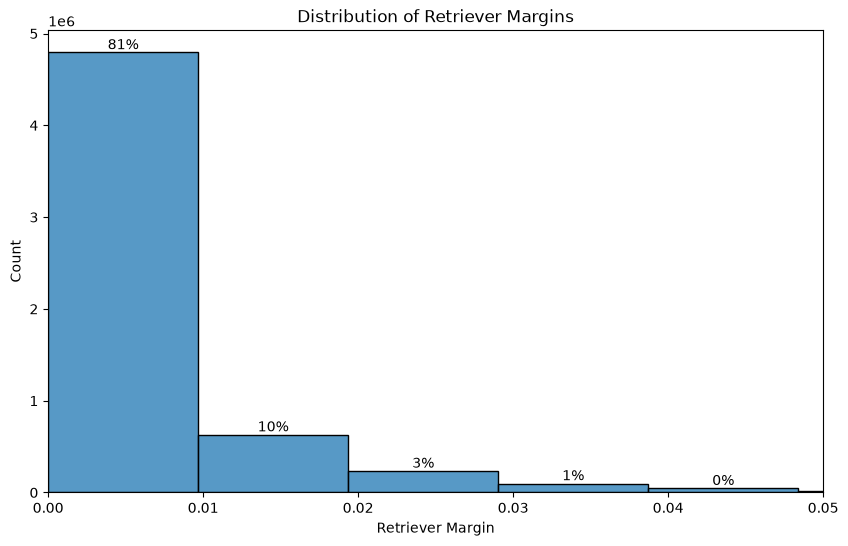

In [223]:
# Drop any values where no retriever results were found.
cand = cand.dropna(subset=["top_retriever_loinc"])

retriever_margins = cand[["retriever_margins"]].explode("retriever_margins").rename(columns={"retriever_margins": "retriever_margin"}).copy().reset_index(drop=True)

# Create a histogram of the retriever margins.
plt.figure(figsize=(10, 6))
sns.histplot(retriever_margins, x="retriever_margin", bins=20, kde=False)
plt.xlabel("Retriever Margin")
plt.ylabel("Count")
plt.title("Distribution of Retriever Margins")
#limit x-axis to focus on the range of interest
plt.xlim(0.0, 0.05)
# Add % to each bar
total = len(retriever_margins)
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height() / total * 100)}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()

The distribution of retriever margins show that the majority of margins are very small. That is, many of the retriever results are very similar to each other. With very slim margins between the different results, it may be difficult to pick a threshold that does not toss out valuable results.

### What does the distribution of retriever margins look like between each rank position?
We wouldn't prune results by rank (too blunt of a tool) but this is a first step to understanding if pursuing a pruning/truncation approach will actually remove any options.

In [ ]:
# Data set up
retriever_margins_rank = cand[["retriever_margins"]].explode("retriever_margins").rename(columns={"retriever_margins": "retriever_margin"}).copy()
retriever_margins_rank["rank"] = retriever_margins_rank.groupby(level=0).cumcount() + 1

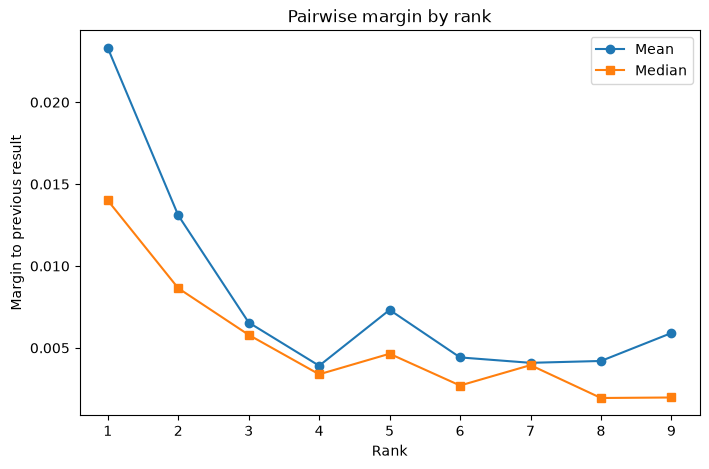

In [204]:
margin_by_rank = (
    retriever_margins_rank
    .reset_index()
    .groupby("rank")["retriever_margin"]
    .agg(["mean", "median", "std"])
)

plt.figure(figsize=(8, 5))
plt.plot(margin_by_rank.index, margin_by_rank["mean"], marker="o", label="Mean")
plt.plot(margin_by_rank.index, margin_by_rank["median"], marker="s", label="Median")
plt.xlabel("Rank")
plt.ylabel("Margin to previous result")
plt.title("Pairwise margin by rank")
plt.legend()
plt.show()

Looks like rank 1 and 2 and 3 are evenly spaced from each other but everything beyond that is roughly clustered together.

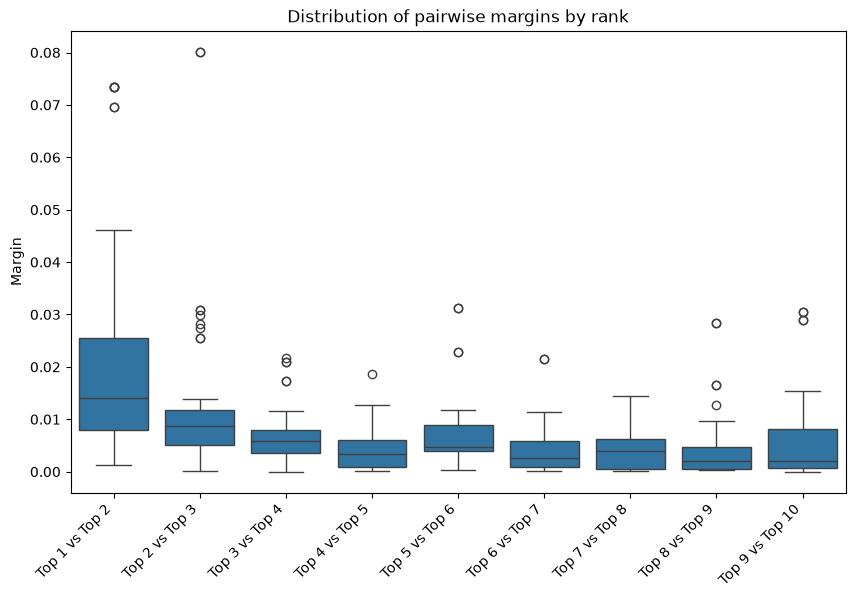

In [201]:
# Distributions of margins for each rank
plot_df = retriever_margins_rank.reset_index()

labels = {
    1: "Top 1 vs Top 2",
    2: "Top 2 vs Top 3",
    3: "Top 3 vs Top 4",
    4: "Top 4 vs Top 5",
    5: "Top 5 vs Top 6",
    6: "Top 6 vs Top 7",
    7: "Top 7 vs Top 8",
    8: "Top 8 vs Top 9",
    9: "Top 9 vs Top 10",}

plot_df["rank_diff_label"] = (
    plot_df["rank"]
    .map(labels)
    .fillna("Top 10+")
)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=plot_df,
    x="rank_diff_label",
    y="retriever_margin",
)
plt.suptitle("")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of pairwise margins by rank")
plt.ylabel("Margin")
plt.xlabel("")
plt.show()


This graph shows the distribution of margins between each ranking (e.g., Top 1 rank vs Top 2). We can see that Top 1 vs Top 2 has the widest range, suggesting that the retriever generally picks a top LOINC and the rest are grouped more closely together.

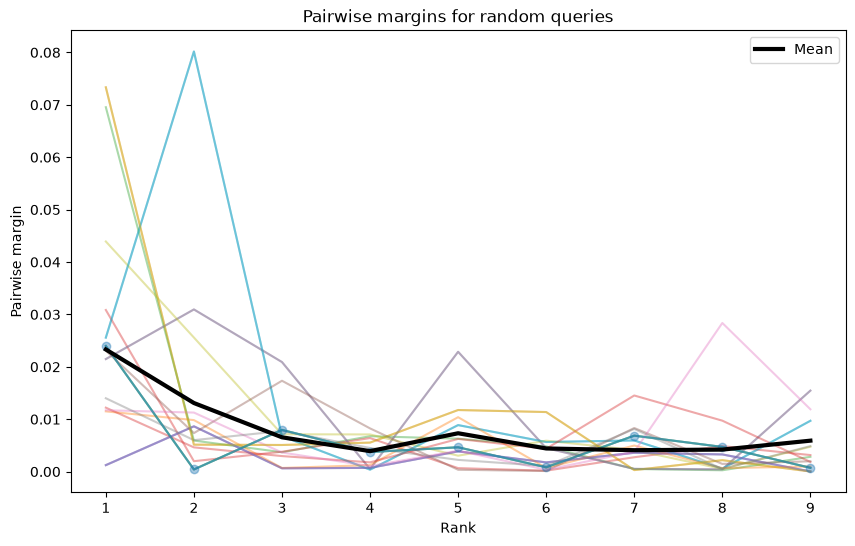

In [215]:
# Cluster visualization for individual queries
ids = retriever_margins_rank.index.get_level_values(0).unique()

sample_ids = (
    pd.Series(ids)
    .sample(20, random_state=0)
    .tolist()
)

plt.figure(figsize=(10, 6))

for pid in sample_ids:
    g = retriever_margins_rank.loc[pid]
    plt.plot(
        g["rank"],
        g["retriever_margin"],
        alpha=0.4
    )

plt.xlabel("Rank")
plt.ylabel("Pairwise margin")
plt.title("Pairwise margins for random queries")
plt.plot(
    g["rank"],
    g["retriever_margin"],
    marker="o",
    alpha=0.4
)
mean_margin = (
    retriever_margins_rank
    .groupby("rank")["retriever_margin"]
    .mean()
)

plt.plot(
    mean_margin.index,
    mean_margin.values,
    color="black",
    linewidth=3,
    label="Mean"
)
plt.legend()
plt.show()


The thin lines show the variability across individual queries, while the thick line reveals whether there are consistent break points (e.g., a noticeable jump between ranks 3→4 or 5→6). If those jumps exist in the mean and many individual traces, that's good evidence that the pairwise truncation rule is capturing a real pattern rather than random variation.

## Candidate Set Boundary Analysis

### How many results are we pruning off at different thresholds?

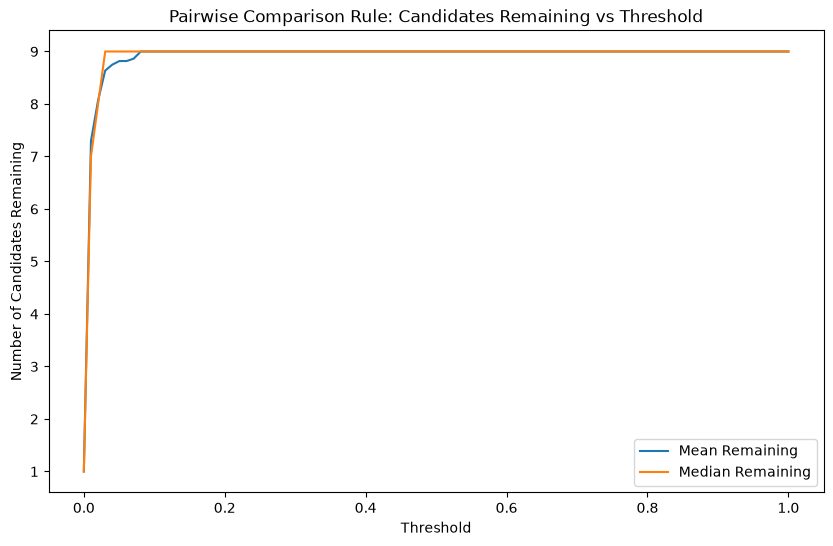

In [189]:
# Pairwise Rule: Drop rank k+1 if margin(rank k, rank k+1) > threshold
def pairwise_threshold(df, threshold):
    df = df.copy()

    # rank 1 always survives
    df["keep"] = True

    # margin at rank k controls whether rank k+1 survives
    df["keep_next"] = df["retriever_margin"] <= threshold

    # shift within ID
    df["keep"] = (
        df.groupby(level=0)["keep_next"]
          .shift(1)
          .fillna(True)
    )

    kept_counts = (
        df.groupby(level=0)["keep"]
          .sum()
    )

    return {
        "mean_remaining": kept_counts.mean(),
        "median_remaining": kept_counts.median(),
        "counts": kept_counts,
    }

thresholds = np.linspace(0, 1, 100)

results = []

for t in thresholds:
    stats = pairwise_threshold(retriever_margins_rank, t)

    results.append({
        "threshold": t,
        "mean_remaining": stats["mean_remaining"],
        "median_remaining": stats["median_remaining"],
    })

results = pd.DataFrame(results)

# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["mean_remaining"], label="Mean Remaining")
plt.plot(results["threshold"], results["median_remaining"], label="Median Remaining")
plt.xlabel("Threshold")
plt.ylabel("Number of Candidates Remaining")
plt.title("Pairwise Comparison Rule: Candidates Remaining vs Threshold")
plt.legend()


(0.0, 0.1)

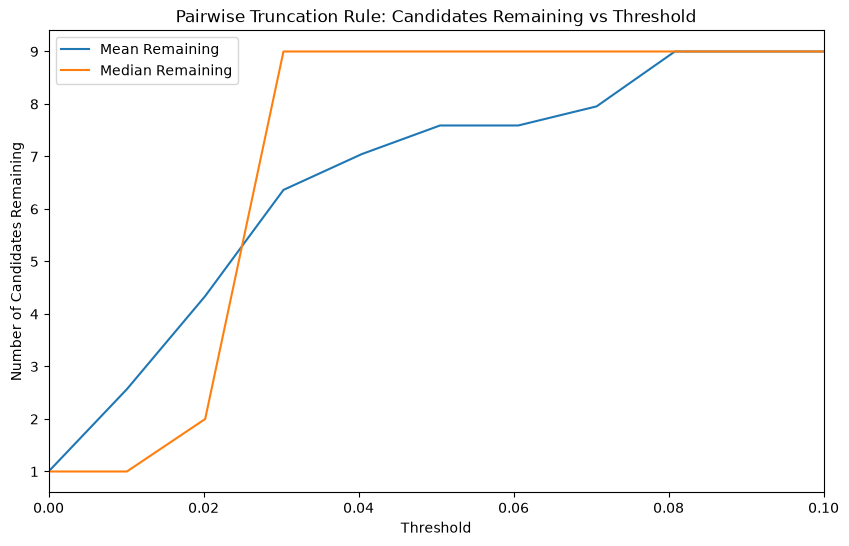

In [192]:
# Pairwise Truncation Rule: As soon as a pairwise margin exceeds threshold, stop.
def truncation_pairwise(group, threshold):
    margins = group["retriever_margin"].values

    exceed = np.where(margins > threshold)[0]

    if len(exceed) == 0:
        return len(group)

    first_break = exceed[0]

    return first_break + 1

thresholds = np.linspace(0, 1, 100)

results = []

grouped = retriever_margins_rank.groupby(level=0)

for t in thresholds:
    counts = grouped.apply(truncation_pairwise, threshold=t)

    results.append({
        "threshold": t,
        "mean_remaining": counts.mean(),
        "median_remaining": counts.median(),
    })

results = pd.DataFrame(results)

# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["mean_remaining"], label="Mean Remaining")
plt.plot(results["threshold"], results["median_remaining"], label="Median Remaining")
plt.xlabel("Threshold")
plt.ylabel("Number of Candidates Remaining")
plt.title("Pairwise Truncation Rule: Candidates Remaining vs Threshold")
plt.legend()
# set the x axis limits to 0-0.02
plt.xlim(0, 0.1)


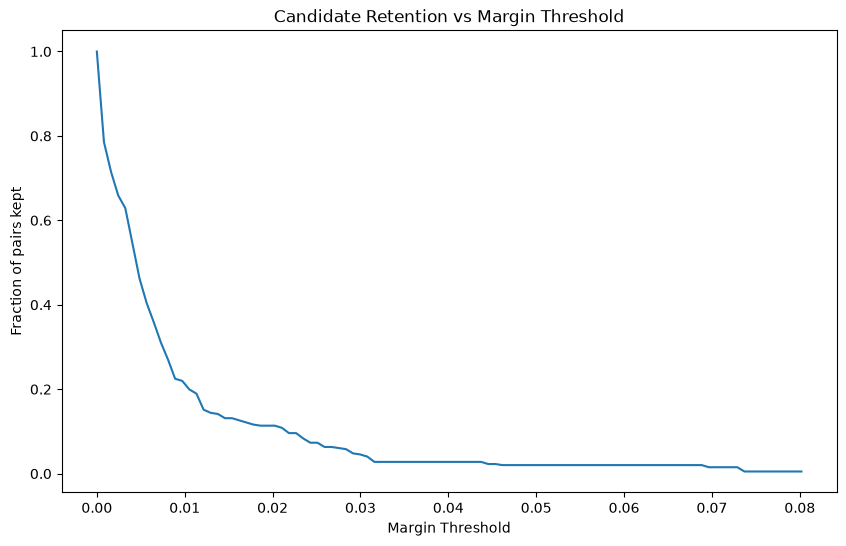

In [123]:
import numpy as np

m = retriever_margins_rank["retriever_margin"].dropna()

thresholds = np.linspace(0, m.max(), 100)

survival = [(m >= t).mean() for t in thresholds]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, survival)

plt.xlabel("Margin Threshold")
plt.ylabel("Fraction of pairs kept")
plt.title("Candidate Retention vs Margin Threshold")
plt.show()

## Manual Inspection
### What do the results look like for the ones that we keep and the ones that we throw away?
Are we auto-rejecting good results? Are we keeping bad ones?

In [54]:
# Highest scoring candidates where the retriever and reranker disagree on the top choice.
cand[["candidate_text","top_retriever_score","top_retriever_text","top_retriever_loinc","reranker_top_decision","reranker_top_score","final_loinc","reranker_chosen_rank"]].sort_values(by="top_retriever_score", ascending=False).head(20)

,candidate_text,top_retriever_score,top_retriever_text,top_retriever_loinc,reranker_top_decision,reranker_top_score,final_loinc,reranker_chosen_rank
6,pH,1.000000,pH,2753-2,pH Spec,0.887252,17433-4,6.0
33,designer benzodiazepines ur ql cfm,1.000000,Designer benzodiazepines Ur Ql Cfm,99262-8,Designer benzodiazepines Ur Ql,0.994603,107210-7,2.0
34,designer benzodiazepines ur ql cfm,1.000000,Designer benzodiazepines Ur Ql Cfm,99262-8,Designer benzodiazepines Ur Ql,0.994603,107210-7,2.0
14,synthetic cannabinoids ur ql cfm,0.995950,Cannabinoids synthetic Ur Ql Cfm,67126-3,Cannabinoids synthetic Ur Ql,0.994744,107208-1,2.0
13,synthetic cannabinoids ur ql cfm,0.995950,Cannabinoids synthetic Ur Ql Cfm,67126-3,Cannabinoids synthetic Ur Ql,0.994744,107208-1,2.0
18,hydrocodone ur CMP,0.940895,HYDROcodone Ur-mCnc,3681-4,HYDROcodone [Presence] in Urine,0.930281,12308-3,9.0
17,hydrocodone ur CMP,0.940895,HYDROcodone Ur-mCnc,3681-4,HYDROcodone [Presence] in Urine,0.930281,12308-3,9.0
39,oxycodone ur CMP,0.937363,oxyCODONE Ur-mCnc,11246-6,oxyCODONE [Presence] in Urine,0.951087,10998-3,10.0
38,oxycodone ur CMP,0.937363,oxyCODONE Ur-mCnc,11246-6,oxyCODONE [Presence] in Urine,0.951087,10998-3,10.0
16,gabapentin ur CMP,0.932627,Gabapentin Ur-mCnc,59680-9,Gabapentin:PrThr:Pt:Urine:Ord:,0.954551,68439-9,10.0


In [55]:
# Lowest scoring candidates where the retriever and reranker disagree on the top choice.
cand[["candidate_text","top_retriever_score","top_retriever_text","top_retriever_loinc","reranker_top_decision","reranker_top_score","final_loinc","reranker_chosen_rank"]].sort_values(by="top_retriever_score", ascending=True).head(20)

,candidate_text,top_retriever_score,top_retriever_text,top_retriever_loinc,reranker_top_decision,reranker_top_score,final_loinc,reranker_chosen_rank
23,nps not otherwise specified ur ql cfm,0.824384,Norpropoxyph Ur Ql Cfm,17376-5,PCP Ur Ql Cfm,0.910033,18392-1,2.0
24,nps not otherwise specified ur ql cfm,0.824384,Norpropoxyph Ur Ql Cfm,17376-5,PCP Ur Ql Cfm,0.910033,18392-1,2.0
32,dehydrotizanidine ur cfm-mcnc,0.832659,Deschloroetizolam Ur Cfm-mCnc,99266-9,traZODone Ur Cfm-mCnc,0.959701,92637-8,9.0
31,dehydrotizanidine ur cfm-mcnc,0.832659,Deschloroetizolam Ur Cfm-mCnc,99266-9,traZODone Ur Cfm-mCnc,0.959701,92637-8,9.0
47,dehydrotizanidine ur cfm-mcnc,0.832659,Deschloroetizolam Ur Cfm-mCnc,99266-9,traZODone Ur Cfm-mCnc,0.959701,92637-8,9.0
46,dehydrotizanidine ur cfm-mcnc,0.832659,Deschloroetizolam Ur Cfm-mCnc,99266-9,traZODone Ur Cfm-mCnc,0.959701,92637-8,9.0
7,leukocytes,0.848194,Leukocytes other/Leukocytes in Blood,26471-3,Leukocytes [Presence] in Urine,0.861945,33052-2,3.0
5,protein,0.871525,Protein [Mass/Vol],2885-2,Protein [Presence] in Urine,0.794344,2887-8,4.0
0,blood,0.873474,Volume of Blood,3157-5,Blood temp,0.814282,60834-9,4.0
26,designer opioids ur ql cfm,0.886991,Opiates Ur Ql Cfm,18390-5,Opiates Ur Ql Cfm,0.979572,18390-5,1.0


Initial look at the data above suggests that it may be difficult to implement an auto-rejection threshold because single word candidate texts like `blood` have very similar top retriever scores to candidate texts where TTC could find a plausible LOINC,e.g., `designer opioids ur ql cfm`.